# L4.2 — Scaled Dot-Product Self-Attention

Hands-on notebook for the lesson [`4-2-self-attention.mdx`](../../llm-quest-theory/level-4/4-2-self-attention.mdx).

> **Learning objectives**
> - Implement `Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V` step-by-step in NumPy and PyTorch.
> - Work through the tiny 3-token example from the theory by hand.
> - Visualize the attention matrix as a heatmap, both without and with a causal mask.
> - See numerically **why** we divide by `sqrt(d_k)`.
> - Confirm our from-scratch output matches `torch.nn.functional.scaled_dot_product_attention`.

## Connection to the theory
Covers **§1–§7** of the source `.mdx`. This is the centerpiece of Level 4 — every modern Transformer is this operation, scaled up.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline
print("torch", torch.__version__)

torch 2.2.2


## 1. The worked example from the theory (3 tokens, d_k = 2)

$$Q = K = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \end{bmatrix},\qquad V = \begin{bmatrix} 10 \\ 20 \\ 30 \end{bmatrix}$$

We compute every step by hand, then verify with one line of torch.

In [2]:
Q = np.array([[1.0, 0.0],
              [0.0, 1.0],
              [1.0, 1.0]])
K = Q.copy()
V = np.array([[10.0],
              [20.0],
              [30.0]])
d_k = Q.shape[-1]

# Step 1: QK^T
scores = Q @ K.T
print("Q K^T =\n", scores)

# Step 2: scale
scaled = scores / np.sqrt(d_k)
print("\nscaled scores =\n", np.round(scaled, 3))

# Step 3: row-wise softmax
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

attn = softmax(scaled, axis=1)
print("\nattention weights (rows sum to 1):\n", np.round(attn, 3))
print("row sums =", attn.sum(axis=1))

# Step 4: weighted sum of V
out_hand = attn @ V
print("\noutput =", out_hand.ravel())

Q K^T =
 [[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

scaled scores =
 [[0.707 0.    0.707]
 [0.    0.707 0.707]
 [0.707 0.707 1.414]]

attention weights (rows sum to 1):
 [[0.401 0.198 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]
row sums = [1. 1. 1.]

output = [20.         22.03336278 22.55234765]


## 2. Cross-check with PyTorch's built-in attention
`torch.nn.functional.scaled_dot_product_attention` expects `(batch, heads, seq, d_head)`. We add two leading dims and compare.

In [3]:
Q_t = torch.tensor(Q).unsqueeze(0).unsqueeze(0)    # (1, 1, 3, 2)
K_t = torch.tensor(K).unsqueeze(0).unsqueeze(0)
V_t = torch.tensor(V).unsqueeze(0).unsqueeze(0)

out_torch = F.scaled_dot_product_attention(Q_t, K_t, V_t).squeeze().numpy()
print("hand-computed out:", np.round(out_hand.ravel(),  6))
print("torch        out:", np.round(out_torch.ravel(), 6))
print("max |hand - torch| =", float(np.max(np.abs(out_hand.ravel() - out_torch.ravel()))))

hand-computed out: [20.       22.033363 22.552348]
torch        out: [20.       22.033363 22.552348]
max |hand - torch| = 0.0


## 3. A reusable `self_attention` function
Clean NumPy version we can use to visualize on longer sequences.

In [4]:
def self_attention(Q, K, V, mask=None):
    """Q, K, V: (T, d_k).  mask: (T, T) with 0 where allowed and -inf where not."""
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    if mask is not None:
        scores = scores + mask
    attn = softmax(scores, axis=-1)
    return attn @ V, attn

## 4. A toy sentence — who pays attention to whom?
We hand-craft 6 tokens where each token has a distinct "key" pattern. This is a static illustration — the real power comes once these matrices are *learned*.

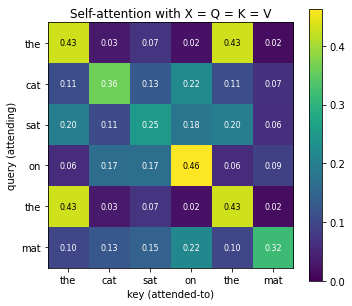

In [5]:
rng = np.random.default_rng(SEED)
tokens = ["the", "cat", "sat", "on", "the", "mat"]
T = len(tokens)
d_k = 8

# Random embeddings for each token
X = rng.normal(size=(T, d_k))
# Lock "the" (positions 0 and 4) to have the same embedding
X[4] = X[0]

# Using X directly as Q=K=V highlights lexical similarity.
_, attn = self_attention(X, X, X)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(attn, cmap="viridis", vmin=0, vmax=attn.max())
ax.set_xticks(range(T)); ax.set_xticklabels(tokens)
ax.set_yticks(range(T)); ax.set_yticklabels(tokens)
ax.set_xlabel("key (attended-to)"); ax.set_ylabel("query (attending)")
for i in range(T):
    for j in range(T):
        ax.text(j, i, f"{attn[i, j]:.2f}", ha="center", va="center",
                color="white" if attn[i, j] < 0.4 else "black", fontsize=8)
plt.colorbar(im, ax=ax); plt.title("Self-attention with X = Q = K = V"); plt.show()

Because `the` at positions 0 and 4 share the same embedding, their rows are (nearly) identical — and the two `the` tokens strongly attend to each other.

## 5. Causal (masked) self-attention
Decoders must not peek at the future. Add a mask with `-inf` above the diagonal, so softmax pushes those cells to 0.

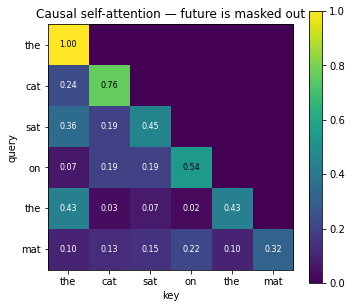

In [6]:
def causal_mask(T):
    # Upper triangular mask with -inf above the diagonal
    m = np.full((T, T), -np.inf)
    return np.triu(m, k=1) + 0  # 0 on and below the diagonal, -inf above

mask = causal_mask(T)
_, attn_causal = self_attention(X, X, X, mask=mask)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(attn_causal, cmap="viridis", vmin=0, vmax=attn_causal.max())
ax.set_xticks(range(T)); ax.set_xticklabels(tokens)
ax.set_yticks(range(T)); ax.set_yticklabels(tokens)
ax.set_xlabel("key"); ax.set_ylabel("query")
for i in range(T):
    for j in range(T):
        if attn_causal[i, j] > 1e-6:
            ax.text(j, i, f"{attn_causal[i, j]:.2f}", ha="center", va="center",
                    color="white" if attn_causal[i, j] < 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax); plt.title("Causal self-attention — future is masked out"); plt.show()

## 6. Why divide by sqrt(d_k)?

If `q` and `k` are random unit-variance vectors, then `q · k` has variance `d_k`. For large `d_k`, the scores become extreme — softmax collapses to one-hot and gradients vanish. Scaling by `1/sqrt(d_k)` brings variance back to 1.

We reproduce that phenomenon empirically below.

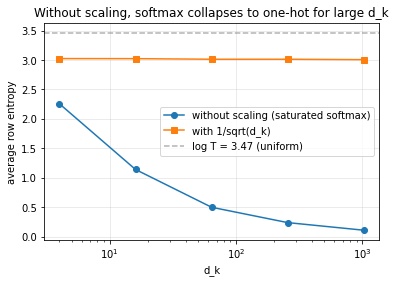

In [7]:
def score_entropy(d_k, T=32, n_trials=50, scale=False):
    # Entropy of each row of the attention matrix, averaged over trials
    ents = []
    for _ in range(n_trials):
        Q = np.random.randn(T, d_k)
        K = np.random.randn(T, d_k)
        scores = Q @ K.T
        if scale:
            scores = scores / np.sqrt(d_k)
        a = softmax(scores, axis=-1)
        row_ent = -np.sum(a * np.log(a + 1e-12), axis=-1)
        ents.append(row_ent.mean())
    return np.mean(ents)

d_values = [4, 16, 64, 256, 1024]
unscaled = [score_entropy(d, scale=False) for d in d_values]
scaled   = [score_entropy(d, scale=True)  for d in d_values]
max_ent  = np.log(32)

fig, ax = plt.subplots()
ax.plot(d_values, unscaled, "o-", label="without scaling (saturated softmax)")
ax.plot(d_values, scaled,   "s-", label="with 1/sqrt(d_k)")
ax.axhline(max_ent, linestyle="--", color="gray", alpha=0.6, label=f"log T = {max_ent:.2f} (uniform)")
ax.set_xscale("log"); ax.set_xlabel("d_k"); ax.set_ylabel("average row entropy")
ax.grid(alpha=0.3); ax.legend()
ax.set_title("Without scaling, softmax collapses to one-hot for large d_k")
plt.show()

Read: entropy near `log(T)` means a uniform-ish distribution (softmax is healthy). Near 0 means one column eats all the mass (softmax saturated, gradients vanish). Without scaling the dot-product attention collapses for large `d_k`; with scaling it stays close to uniform for the same embeddings.

## 7. Complexity check: O(T^2) memory and compute

In [8]:
import time
for T_bench in [64, 256, 1024, 2048]:
    Q = torch.randn(T_bench, 64)
    K = torch.randn(T_bench, 64)
    V = torch.randn(T_bench, 64)
    t0 = time.time()
    for _ in range(3):
        with torch.no_grad():
            attn_bench = F.softmax(Q @ K.T / np.sqrt(64), dim=-1)
            _ = attn_bench @ V
    dt = (time.time() - t0) / 3
    mem = T_bench * T_bench * 4 / 1024 / 1024   # attn matrix in float32 MB
    print(f"T = {T_bench:>5}  time ~ {1000*dt:6.2f} ms  attn-matrix memory ~ {mem:7.2f} MB")

T =    64  time ~   1.52 ms  attn-matrix memory ~    0.02 MB
T =   256  time ~   0.87 ms  attn-matrix memory ~    0.25 MB
T =  1024  time ~   9.13 ms  attn-matrix memory ~    4.00 MB
T =  2048  time ~  28.82 ms  attn-matrix memory ~   16.00 MB


Doubling T roughly quadruples both time and memory — that is the O(T^2) wall modern LLM-context techniques (FlashAttention, sliding window, Mamba) are fighting.

## 8. Quick checks

In [9]:
# Our hand computation must match torch
assert np.allclose(out_hand.ravel(), out_torch.ravel(), atol=1e-6)
# Rows of softmax must sum to 1
assert np.allclose(attn.sum(axis=1), 1.0)
# Causal mask must give strict zeros above the diagonal
upper = attn_causal[np.triu_indices(T, k=1)]
assert (upper == 0).all(), "future positions must be fully masked out"
# Each causal row still sums to 1
assert np.allclose(attn_causal.sum(axis=1), 1.0)
# Scaling really helps keep entropy up
assert scaled[-1]  > unscaled[-1],  "scaling must keep softmax healthier at large d_k"
print("OK — self-attention built from scratch, masks behave, and scaling is necessary.")

OK — self-attention built from scratch, masks behave, and scaling is necessary.


## Reflection questions

1. If we set `W_Q = W_K`, the attention matrix becomes symmetric. What does that mean for "pronoun ↔ antecedent" relationships?
2. Why is the causal mask added as `-inf` *before* softmax, rather than multiplying the attention weights by `0` *after* softmax?
3. Your toy sentence uses `X` directly as `Q`, `K`, `V`. In a real transformer these come from learned projections. What extra flexibility does that add?
4. FlashAttention computes the same output as our function but with `O(T)` memory. How is that possible when the attention matrix itself is `T×T`?

## References
- Source theory: [`4-2-self-attention.mdx`](../../llm-quest-theory/level-4/4-2-self-attention.mdx)
- Next: [`4-3-positional-encoding`](4-3-positional-encoding.ipynb)